## **MODUL 1: KICAUUU MANIAA**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

*Mengimport library Python seperti OpenCV (untuk pengolahan citra dan video), matplotlib (untuk visualisasi data), dan NumPy (untuk operasi matematika)*

#### *Menampilkan citra 1

mengimpor data gambar dari penyimpanan lokal ke dalam variabel dengan membacanya menggunakan OpenCV, mengubah urutan warnanya dari standar OpenCV (BGR) ke standar umum (RGB), lalu menampilkannya menggunakan Matplotlib dengan judul "Citra 1"

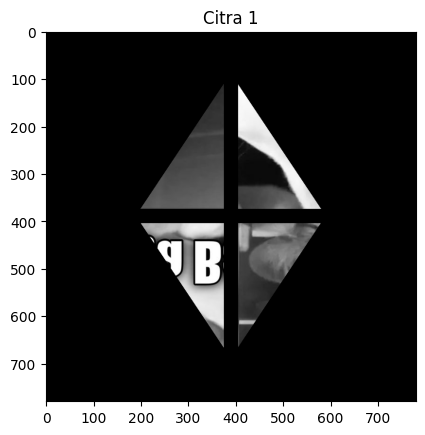

In [2]:
img_gray = cv2.imread("Asset/citra1.png")
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_BGR2RGB)

plt.title("Citra 1")
plt.imshow(img_rgb, cmap='gray')
plt.show()

#### Menampilkan citra 2

mengimpor data gambar dari penyimpanan lokal ke dalam variabel dengan membacanya menggunakan OpenCV, mengubah urutan warnanya dari standar OpenCV (BGR) ke standar umum (RGB), lalu menampilkannya menggunakan Matplotlib dengan judul "Citra 2"

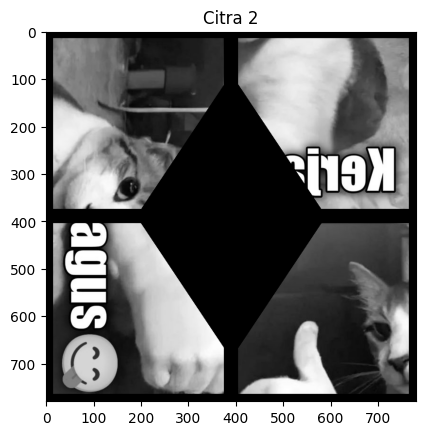

In [3]:
img_gray2 = cv2.imread("Asset/citra2.png")
img_rgb2 = cv2.cvtColor(img_gray2, cv2.COLOR_BGR2RGB)

plt.title("Citra 2")
plt.imshow(img_rgb2, cmap='gray')
plt.show()

In [4]:
def fungsi_empat_R(img, val):
    h,w = img.shape[:2]
    val = int(val) % 360

    if val < 90:
        rot = np.zeros((w,h), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[j, h-1-i] = img[i,j]
        return rot   
    elif val == 180:
        rot = np.zeros_like(img, dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[h-1-i, w-1-j] = img[i,j]
        return rot
    elif val == 270:
        rot = np.zeros((w,h), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[w-1-j, i] = img[i,j]
        return rot
    return img

kode diatas merupakan fungsi rotasi yang akan menampilkan matrix sesuai jumlah/arah derajat rotasi yang diinginkan

pemanggilan fungsi untuk memproses citra 1 grayscale dengan parameter rotasi 180 derajat, dilanjutkan dengan penyajian hasil olahan agar perubahan posisi piksel dapat diamati secara visual.

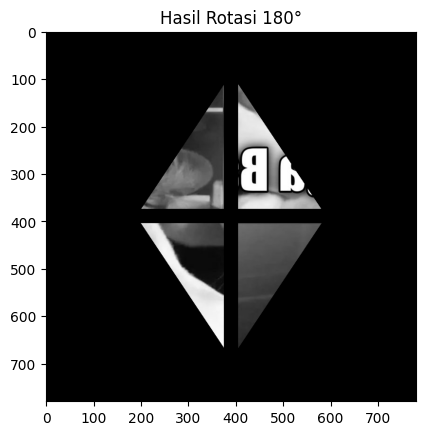

In [5]:
hasil_rotasi = fungsi_empat_R(img_rgb, 180)

plt.title("Hasil Rotasi 180°")
plt.imshow(hasil_rotasi, cmap='gray')

plt.show()

In [6]:
def fungsi_dua_a(citra_1, citra_2):
    return (citra_1.astype(float) / 2 + citra_2.astype(float) / 2).astype(np.uint8)

def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

fungsi ini menangani penyatuan dua citra melalui tiga metode: aritmatika (penjumlahan matriks piksel untuk efek blending), serta penggabungan dimensi baik secara horizontal (sejajar samping) maupun vertikal (sejajar atas-bawah).

proses dimana citra 1 hasil rotasi 180 derajat digabungkan kembali dengan citra asli menggunakan fungsi penyatuan ruang. Tampilannya adalah citra tumpuk (blending) yang kemudian divisualisasikan untuk melihat hasil penyatuan dari 2 buah citra.

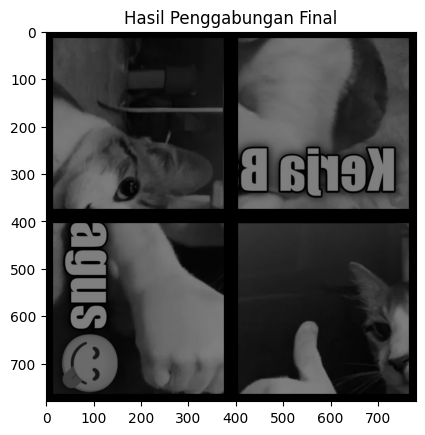

In [7]:
hasil_rotasi = fungsi_empat_R(img_rgb, 180)
hasil_final = fungsi_dua_a(img_rgb2, hasil_rotasi)

plt.title("Hasil Penggabungan Final")
plt.imshow(hasil_final, cmap='gray')
plt.show()

In [8]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :, :] if mode == 'H' else gambar[:, a:b, :]

Kode di atas merupakan fungsi manipulasi matriks citra yang akan menampilkan area gambar sesuai dengan batasan rentang koordinat dan arah orientasi yang diinginkan. Melalui parameter mode 'H' atau 'V', kita bisa mengatur arah pemotongan matriksnya, baik secara horizontal (searah baris) maupun vertikal (searah kolom).

Kode dibawah melakukan segmentasi citra dengan membagi hasil final menjadi empat bagian (kiri-kanan, atas-bawah) melalui pemotongan koordinat baris dan kolom. Hasil potongan tersebut kemudian disusun ke dalam layout grid 2x2 menggunakan subplot untuk mempermudah perbandingan visual antar tiap fragmen citra dalam satu tampilan.

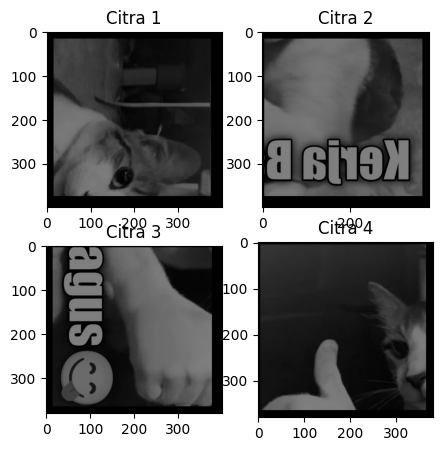

In [9]:
bagian_atas = fungsi_empat_S(hasil_final, 0, 400, mode='H')
bagian_bawah = fungsi_empat_S(hasil_final, 400, 800, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 400, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 400, 800, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 400, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 400, 800, mode='V') 

plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(citra_1, cmap='gray')

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(citra_2, cmap='gray')

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(citra_3, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(citra_4, cmap='gray')

plt.show()

In [10]:
def fungsi_satu(image, mode='X'):
    h, w = image.shape[:2]
    hasil = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

Kode di atas merupakan fungsi untuk membuat efek mirroring atau pencerminan pada gambar sesuai dengan arah yang diinginkan. Kalau kita pakai mode 'X', gambar bakal dicerminkan secara horizontal (membalik kolom), sedangkan mode 'Y' untuk mencerminkan gambar secara vertikal (membalik baris) dengan cara membalik urutan indeks pikselnya.

Kode dibawah berfungsi untuk mengambil sebagian area gambar di sebelah kanan (baik atas maupun bawah), lalu bagian tersebut kita cerminkan secara horizontal (mirroring). Setelah itu, hasilnya kita tampilkan dalam dua panel visual berdampingan untuk melihat perbandingan dan membuktikan apakah efek pembalikan pikselnya sudah berhasil atau belum pada area yang dipilih.

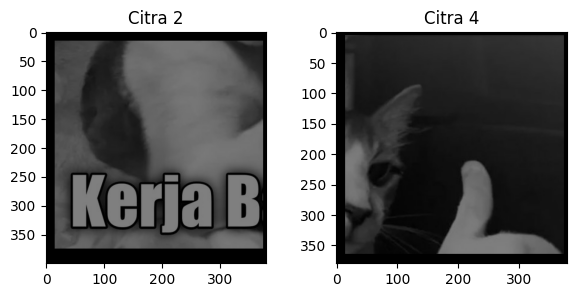

In [11]:
bagian_atas = fungsi_empat_S(hasil_final, 0, 400, mode='H')
bagian_bawah = fungsi_empat_S(hasil_final, 400, 800, mode='H')

citra_2_asli = fungsi_empat_S(bagian_atas, 400, 800, mode='V')
citra_4_asli = fungsi_empat_S(bagian_bawah, 400, 800, mode='V')

hasil_flipping_c2 = fungsi_satu(citra_2_asli, mode='X')
hasil_flipping_c4 = fungsi_satu(citra_4_asli, mode='X')

plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("Citra 2")
plt.imshow(hasil_flipping_c2, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Citra 4")
plt.imshow(hasil_flipping_c4, cmap='gray')
plt.show()

In [12]:
def fungsi_rotasi_90_ccw(image):
    h, w = image.shape[:2]
    hasil = np.zeros((w, h) + image.shape[2:], dtype=image.dtype)
    
    for i in range(h):
        for j in range(w):
            hasil[w - 1 - j, i] = image[i, j]
            
    return hasil

Kode di atas merupakan fungsi rotasi yang akan memutar gambar sejauh 90 derajat berlawanan arah jarum jam (ke kiri). Proses ini dilakukan dengan cara menukar posisi baris dan kolom matriks gambar (tinggi dan lebar), lalu mengatur ulang posisi pikselnya supaya posisi gambar yang awalnya tegak bisa berubah miring ke arah kiri.

Kode dibawah berfungsi untuk memutar gambar di bagian sebelah kiri saja (atas dan bawah) sejauh 90 derajat berlawanan arah jarum jam. Setelah orientasi gambar di area tersebut kita ubah, hasilnya kita tampilkan berdampingan dalam sebuah layout perbandingan untuk mengecek apakah posisi pikselnya sudah berputar dengan benar atau belum.

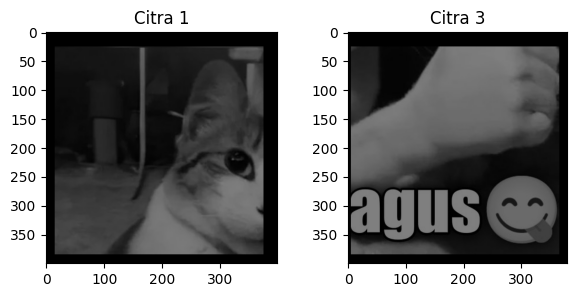

In [13]:
hasil_rotasi_c1 = fungsi_rotasi_90_ccw(citra_1)
hasil_rotasi_c3 = fungsi_rotasi_90_ccw(citra_3)

plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("Citra 1")
plt.imshow(hasil_rotasi_c1, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Citra 3")
plt.imshow(hasil_rotasi_c3, cmap='gray')

plt.show()

In [14]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0):
    image = np.array(image)
    h, w = image.shape[:2]
    
    hasil = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x

            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
                
    return hasil

Kode di atas merupakan fungsi translasi yang digunakan untuk menggeser posisi gambar ke arah sumbu X dan sumbu Y yang kita inginkan. Di sini ada fungsi pengecekan batasnya juga, jadi kalau gambar digeser melebihi ukuran bingkai, pikselnya tidak akan dicetak, dan area kosong yang ditinggalkan otomatis bakal berubah warna jadi hitam.

Di bagian ini, kita menggeser posisi tiap potongan gambar pakai fungsi translasi agar objek atau teks di dalamnya bisa pas dan saling nyambung. Kita tinggal memasukkan nilai koordinat X dan Y yang berbeda untuk setiap potongan gambar supaya posisinya pas sebelum kita tampilkan semuanya bersamaan dalam satu grid.

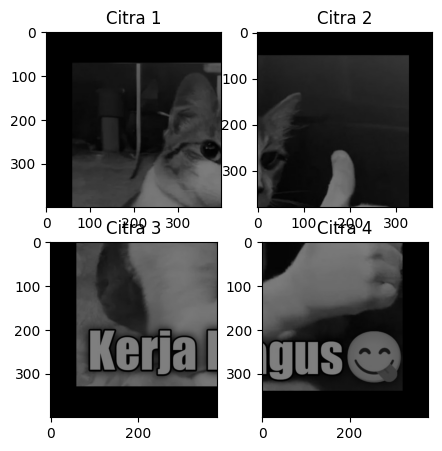

In [15]:
c1_final = fungsi_lima(hasil_rotasi_c1, geser_kolom_x=45, geser_baris_y=45)
c2_final = fungsi_lima(hasil_flipping_c4, geser_kolom_x=-45, geser_baris_y=45)
c3_final = fungsi_lima(hasil_rotasi_c3, geser_kolom_x=-45, geser_baris_y=-45)
c4_final = fungsi_lima(hasil_flipping_c2, geser_kolom_x=45, geser_baris_y=-45)

plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 1)
plt.imshow(c1_final, cmap='gray') 
plt.title("Citra 1")

plt.subplot(2, 2, 2)
plt.imshow(c2_final, cmap='gray') 
plt.title("Citra 2")

plt.subplot(2, 2, 3)
plt.imshow(c4_final, cmap='gray') 
plt.title("Citra 3")

plt.subplot(2, 2, 4)
plt.imshow(c3_final, cmap='gray') 
plt.title("Citra 4")


plt.show()

In [16]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape[:2]
    dilated_shape = (h * 2, w * 2) + image.shape[2:]
    dilated = np.zeros(dilated_shape, dtype=image.dtype)
  
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y, x] = image[int(y / 2), int(x / 2)]
    
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    hasil = dilated[sy:ey, sx:ex]
    return hasil

Kode diatas merupakan fungsi yang tujuannya untuk menzoom gambar jadi dua kali lipat lebih besar. Caranya dengan membuat matriks baru yang ukurannya dua kali ukuran asli, lalu setiap pikselnya diduplikasi agar gambarnya melebar. Di akhir fungsi, ada logika pemotongan (crop) mengguanakan parameter p1 sampai p4 supaya kita bisa mengatur bagian mana saja dari gambar hasil zoom tadi yang mau diambil atau dibuang area pinggirnya.

Di bagian ini, kita menggabungkan semua teknik yang sudah ada sebelumnya untuk menyusun ulang bagian-bagian gambar. Alurnya dimulai dari memotong gambar jadi empat bagian, memutar atau mencerminkan tiap potongan supaya posisinya pas, sampai melakukan zoom dan cropping untuk merapikan detail objek dan teksnya. Terakhir, hasilnya kita tampilkan dalam grid 2x2 agar kelihatan susunan barunya sudah rapi dan menyatu.

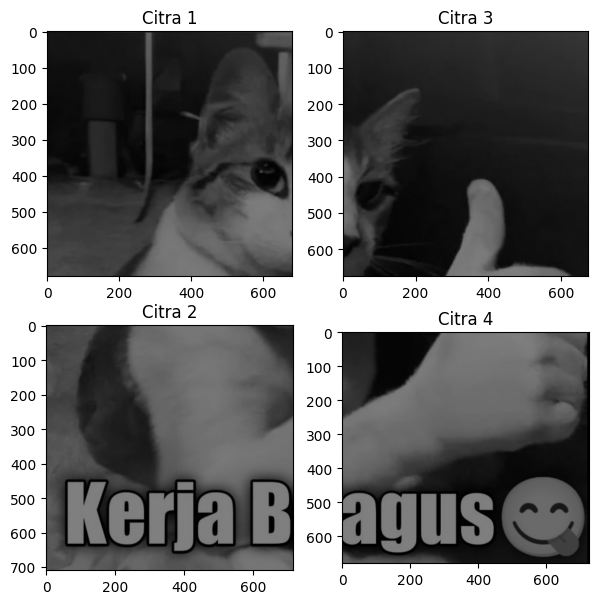

In [17]:
atas = fungsi_empat_S(hasil_final, 0, 400, mode='H')
bawah = fungsi_empat_S(hasil_final, 400, 800, mode='H')

c1_raw = fungsi_empat_S(atas, 0, 400, mode='V')
c2_raw = fungsi_empat_S(atas, 400, 800, mode='V')
c3_raw = fungsi_empat_S(bawah, 0, 400, mode='V')
c4_raw = fungsi_empat_S(bawah, 400, 800, mode='V')

c1_ready = fungsi_rotasi_90_ccw(c1_raw)     
c2_ready = fungsi_satu(c4_raw, mode='X')   
c3_ready = fungsi_satu(c2_raw, mode='X')   
c4_ready = fungsi_rotasi_90_ccw(c3_raw)    


# Citra 1 (Kiri Atas): Potong bawah dan kanan
c1_final = fungsi_tiga(c1_ready, p1=50, p2=70, p3=50, p4=70)
# Citra 2 (Kanan Atas): Potong bawah dan kiri
c2_final = fungsi_tiga(c2_ready, p1=15, p2=70, p3=70, p4=15)
# Citra 3 (Kiri Bawah): Potong atas dan kanan
c3_final = fungsi_tiga(c3_ready, p1=40, p2=50, p3=30, p4=15)
# Citra 4 (Kanan Bawah): Potong atas dan kiri
c4_final = fungsi_tiga(c4_ready, p1=70, p2=50, p3=10, p4=25)

plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.imshow(c1_final, cmap='gray')
plt.title("Citra 1")

plt.subplot(2, 2, 2)
plt.imshow(c2_final, cmap='gray') 
plt.title("Citra 3")

plt.subplot(2, 2, 3)
plt.imshow(c3_final, cmap='gray') 
plt.title("Citra 2")

plt.subplot(2, 2, 4)
plt.imshow(c4_final, cmap='gray') 
plt.title("Citra 4")

plt.show()

Kode pada tahap ini fokus pada merakit ulang (assembling) semua potongan gambar yang sudah diperbaiki. Pertama, ada fungsi 'crop_hitamin' untuk membuang pinggiran hitam yang tidak perlu supaya tiap potongan menjadi bersih. Setelah itu, potongan-potongan tadi digabungkan secara horizontal jadi dua baris, lalu digabung lagi secara vertikal sampai menjadi satu kesatuan gambar utuh dan simetris.

In [18]:
def fungsi_dua_b(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    shape_hasil = (tinggi, lebar) + c1.shape[2:]
    hasil = np.zeros(shape_hasil, dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1], ...] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:, ...] = c2 
    return hasil

def fungsi_dua_c(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    shape_hasil = (tinggi, lebar) + c1.shape[2:]
    hasil = np.zeros(shape_hasil, dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1], ...] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1], ...] = c2 
    return hasil

def crop_hitamin(image):
    if image.dtype == float or image.dtype == np.float32:
        image = np.clip(image, 0, 255).astype(np.uint8)
    
    if image.ndim == 3:
        mask = np.any(image > 0, axis=2)
    else:
        mask = image > 0
    
    baris = np.any(mask, axis=1)
    kolom = np.any(mask, axis=0)
    
    if not np.any(baris) or not np.any(kolom):
        return image
    
    y1, y2 = np.where(baris)[0][[0, -1]]
    x1, x2 = np.where(kolom)[0][[0, -1]]
    return image[y1:y2+1, x1:x2+1]

ketiga fungsi diatas digunakan untuk menggabungkan dan merapikan gambar menggunakan library NumPy

Kode dibawah digunakan untuk memproses 4 gambar secara otomatis, membuang bagian hitamnya, lalu menyatukannya menjadi satu gambar besar berbentuk kotak.

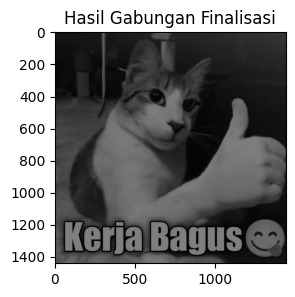

In [19]:
c1_final = crop_hitamin(fungsi_tiga(c1_ready))
c2_final = crop_hitamin(fungsi_tiga(c2_ready))
c3_final = crop_hitamin(fungsi_tiga(c3_ready))
c4_final = crop_hitamin(fungsi_tiga(c4_ready))

baris_atas = fungsi_dua_b(c1_final, c2_final)
baris_bawah = fungsi_dua_b(c3_final, c4_final)
hasil_finalisasi = fungsi_dua_c(baris_atas, baris_bawah)

plt.figure(figsize=(3, 3))
plt.title("Hasil Gabungan Finalisasi")
plt.imshow(hasil_finalisasi, cmap='gray')
plt.show()


Pada tahap terakhir ini, gambar hasil gabungan dari potongan-potongan tadi diperbaiki lagi kualitas tampilannya. Kalau dilihat pada Histogram sebelum Normalisasi (yang warna biru), tampak kalau semua titik warna numpuk di bagian kiri atau area gelap. Ini tandanya gambar yang sudah kita susun sebenarnya masih sangat gelap, bahkan hampir hitam semua, sehingga bentuk muka kucing dan tulisannya nggak kelihatan jelas karena beda warnanya tipis sekali. Kondisi ini biasanya muncul karena nilai-nilai dalam matriks gambarnya masih kecil-kecil setelah diproses tadi.
Untuk memperbaikinya, kita pakai rumus normalisasi supaya sebaran warnanya lebih luas, dari yang paling gelap (0) sampai yang paling terang (255). Hasilnya bisa dilihat di Histogram Setelah Normalisasi (yang warna hijau), di mana titik-titik warnanya sudah menyebar rata di semua bagian. Secara kasat mata, perubahannya sangat terasa; gambar jadi jauh lebih terang dan tajam. Bagian-bagian yang tadi sudah kita putar, geser, dan sambungin kayak kepala kucing, bagian jempol, sampai teks "Kerja Bagus"akhirnya kelihatan jelas dan menyatu dengan pas. Tahap ini penting banget buat memastikan hasil akhir tugas ini tampilannya maksimal dan nyaman dilihat.

Nilai Min Sebelum Normalisasi: 0.0
Nilai Max Sebelum Normalisasi: 127.0


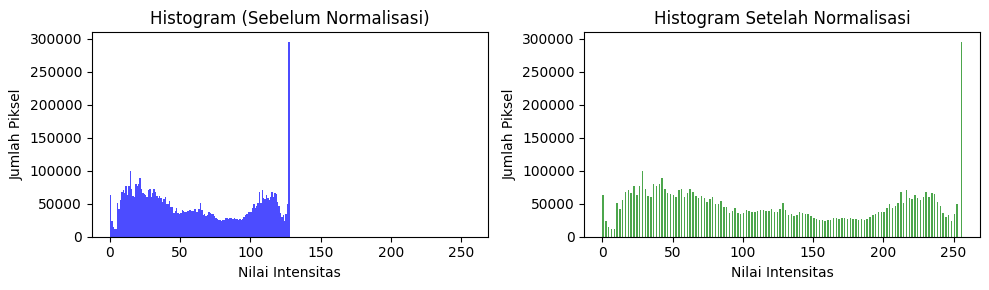

In [20]:
f_min = float(hasil_finalisasi.min())
f_max = float(hasil_finalisasi.max())

print(f"Nilai Min Sebelum Normalisasi: {f_min}")
print(f"Nilai Max Sebelum Normalisasi: {f_max}")

citra_normalisasi = ((hasil_finalisasi.astype(np.float32) - f_min) / (f_max - f_min) * 255).astype(np.uint8)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(hasil_finalisasi.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title("Histogram (Sebelum Normalisasi)")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(1, 2, 2)
plt.hist(citra_normalisasi.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.tight_layout()
plt.show()

Tahap selanjutnya bertujuan untuk memperjelas detail dan garis tepi pada gambar menggunakan teknik konvolusi manual. Pertama, gambar diberi pinggiran tambahan (padding) agar ukurannya tidak menyusut saat diproses. Setelah itu, setiap bagian gambar dihitung menggunakan matriks khusus (kernel) untuk menonjolkan perbedaan warna yang tajam.

Karena hasil hitungannya bisa melesat dari batas warna normal, dilakukan pembatasan nilai (clipping) agar tetap di rentang 0 sampai 255. Hasil akhirnya, detail seperti tekstur bulu kucing dan tepian tulisan jadi lebih tegas dan terlihat jauh lebih tajam serta agak gelap dibandingkan sebelumnya.

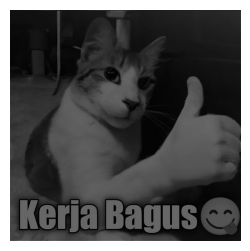

In [21]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def manual_zero_padding(img, ker_shape):
    h, w = img.shape[:2]
    kh, kw = ker_shape
    pad_h = kh // 2
    pad_w = kw // 2
    new_shape = (h + 2*pad_h, w + 2*pad_w) + img.shape[2:]
    padded_img = np.zeros(new_shape, dtype=float)
    padded_img[pad_h:pad_h+h, pad_w:pad_w+w, ...] = img
    return padded_img, pad_h, pad_w

def konvolusi_sikicau(img, kernel):
    h, w = img.shape[:2]
    kh, kw = kernel.shape
    padded_img, pad_h, pad_w = manual_zero_padding(img, (kh, kw))
    hasil = np.zeros_like(img, dtype=float)
    if img.ndim == 3:
        for c in range(img.shape[2]):
            for i in range(h):
                for j in range(w):
                    region = padded_img[i:i+kh, j:j+kw, c]
                    hasil[i, j, c] = np.sum(region * kernel)
    else:
        for i in range(h):
            for j in range(w):
                region = padded_img[i:i+kh, j:j+kw]
                hasil[i, j] = np.sum(region * kernel)
    return hasil

hasil_raw = konvolusi_sikicau(citra_normalisasi, kernel)
citra_final = np.clip(hasil_raw, 0, 255).astype(np.uint8)

plt.figure(figsize=(3, 3))
plt.imshow(citra_final, cmap='gray')
plt.axis('off')
plt.show()

kode berikut fungsinya untuk membuat histogram citra dan grafik hasilnya dengan mengubah matriks gambar menjadi satu dimensi lalu memetakan jumlah piksel ke dalam 256 tingkat kecerahan menggunakan fungsi plt.hist(). Dari grafik yang dihasilkan, terlihat bahwa sebaran piksel menumpuk di sisi kiri antara nilai intensitas 0 hingga 105, yang menandakan bahwa gambar tersebut didominasi oleh warna gelap dan abu-abu. Terdapat juga satu puncak tertinggi di sekitar nilai 102 yang menunjukkan adanya satu warna abu-abu spesifik yang sangat dominan di dalam citra tersebut.

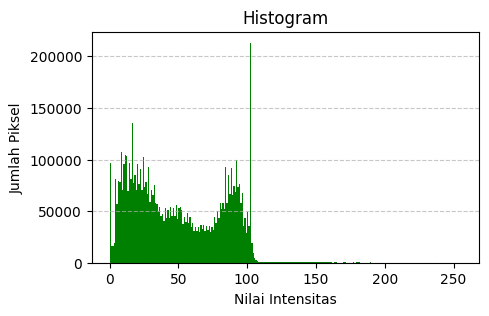

In [22]:
plt.figure(figsize=(5, 3))
plt.hist(citra_final.ravel(), bins=256, range=[0, 256], color='green')
plt.title("Histogram")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Padding dilakukan agar ukuran gambar tidak mengecil setelah diproses. Jika tidak menggunakan padding, piksel pada bagian paling tepi tidak akan terkena kernel penyaring, sehingga ukuran gambar menyusut. Di sini kita menggunakan zero-padding (menambahkan bingkai hitam atau nilai 0 di sekeliling gambar) agar kernel dapat memproses semua piksel asli hingga ke ujung tanpa mengubah isi gambar aslinya. Efeknya terhadap visual adalah tepi gambar tetap aman dan tidak terpotong. Namun pada histogram, penambahan ini akan membuat grafik pada angka 0 melonjak tinggi karena kita memasukkan banyak piksel hitam baru sebagai bingkai.

Konvolusi merupakan proses penyaringan untuk mengambil pola atau fitur gambar dengan cara mengalikan piksel asli dengan matriks bobot (kernel). Tergantung kernel yang digunakan, bagian tepi atau garis objek akan diperjelas kontrasnya, sementara area yang polos akan diredam. Proses ini membuat nilai piksel berubah drastis, bahkan dapat bernilai negatif atau lebih dari 255. Efeknya terhadap visual membuat garis dan sudut objek terlihat lebih tajam, tetapi latar belakangnya menjadi lebih gelap. Pada histogram, sebaran nilainya menjadi sangat lebar sampai melewati batas normal karena perubahan nilai piksel yang ekstrem tersebut.

Proses Clipping dilakukan untuk menormalkan kembali nilai piksel hasil konvolusi ke rentang standar citra 8-bit, yaitu antara 0 sampai 255. Semua nilai di bawah 0 akan dibulatkan ke 0 (hitam), dan nilai di atas 255 akan dipotong menjadi 255 (putih). Secara visual, clipping berfungsi untuk menstabilkan warna gambar agar tidak terjadi overflow warna. Pada histogram, proses ini mengembalikan rentang grafik tepat pada batas 0 sampai 255, sekaligus memicu penumpukan frekuensi di ujung kiri dan kanan akibat pemangkasan nilai ekstrem tersebut.